In [12]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

---
## banco de dados

In [31]:
DB = 'ormuz.db'
if os.path.exists(DB):
    os.remove(DB)

conn = sqlite3.connect(DB)
cur  = conn.cursor()

# Tabela de treino
cur.execute('''
    CREATE TABLE treino (
        id        TEXT,
        evento    TEXT,
        brent_pct REAL,
        petr4_pct REAL,
        vale3_pct REAL
    )''')

cur.executemany('INSERT INTO treino VALUES (?,?,?,?,?)', [
    ('T1', 'Ataques tankers Golfo de Omã',       4.5,  3.8, -0.9),
    ('T2', 'Ataques refinarias Aramco',          14.6, 11.2, -2.4),
    ('T3', 'Assassinato Gen. Soleimani',          4.0,  3.1, -1.1),
    ('T4', 'Incidente IRGC navio israelense',    2.1,  1.8,  0.5),
    ('T5', '7 de Outubro — Hamas ataca Israel',  4.2,  3.3, -1.8),
    ('T6', 'Houthis atacam Mar Vermelho',         3.2,  2.4, -2.3),
    ('T7', 'Ataque Irã direto a Israel',          6.1,  4.8, -2.9),
    ('T8', 'Retaliações mútuas Irã-Israel',       3.8,  2.9, -2.1),
])

# Tabela de teste 2025
cur.execute('''
    CREATE TABLE teste (
        id         TEXT,
        evento     TEXT,
        brent_pct  REAL,
        petr4_real REAL,
        vale3_real REAL
    )''')

cur.executemany('INSERT INTO teste VALUES (?,?,?,?,?)', [
    ('V1', 'OPEC+ cortes — tensão baixa',          0.8,  1.2,  0.9),
    ('V2', 'Houthis retomam ataques',              2.9,  2.1, -1.6),
    ('V3', 'Sanções EUA ao petróleo iraniano',     5.2,  4.3, -3.1),
    ('V4', 'Incidentes com drones no Golfo',       3.6,  3.0, -2.4),
    ('V5', 'Escalada EUA-Irã — pré-crise Ormuz',  7.8,  6.1, -4.2),
    ('V6', 'Brent recua: OPEC+ aumenta produção', -6.5, -4.8, -3.9),
])

# Tabela para guardar os resultados do modelo
cur.execute('''
    CREATE TABLE resultados (
        id         TEXT,
        ativo      TEXT,
        predito    REAL,
        real       REAL,
        erro       REAL,
        acertou    INTEGER
    )''')

conn.commit()
conn.close()

---
## Carregar os dados do banco

In [35]:
conn = sqlite3.connect(DB)
df_treino = pd.read_sql('SELECT * FROM treino', conn)
df_teste  = pd.read_sql('SELECT * FROM teste',  conn)
conn.close()

print(' DADOS DE TREINO (2019-2024) ')
print(df_treino.to_string(index=False))
print()
print(' DADOS DE TESTE 2025')
print(df_teste[['id','evento','brent_pct']].to_string(index=False))

 DADOS DE TREINO (2019-2024) 
id                            evento  brent_pct  petr4_pct  vale3_pct
T1      Ataques tankers Golfo de Omã        4.5        3.8       -0.9
T2         Ataques refinarias Aramco       14.6       11.2       -2.4
T3        Assassinato Gen. Soleimani        4.0        3.1       -1.1
T4   Incidente IRGC navio israelense        2.1        1.8        0.5
T5 7 de Outubro — Hamas ataca Israel        4.2        3.3       -1.8
T6       Houthis atacam Mar Vermelho        3.2        2.4       -2.3
T7        Ataque Irã direto a Israel        6.1        4.8       -2.9
T8     Retaliações mútuas Irã-Israel        3.8        2.9       -2.1

 DADOS DE TESTE 2025
id                              evento  brent_pct
V1         OPEC+ cortes — tensão baixa        0.8
V2             Houthis retomam ataques        2.9
V3    Sanções EUA ao petróleo iraniano        5.2
V4      Incidentes com drones no Golfo        3.6
V5  Escalada EUA-Irã — pré-crise Ormuz        7.8
V6 Brent recua: OP

---
## Treino (2019-2024)

In [ ]:
X  = df_treino['brent_pct'].values
yp = df_treino['petr4_pct'].values
yv = df_treino['vale3_pct'].values

# Regressao Linear OLS
# β = quanto a açao move por cada 1% de variaçao do Brent
# α = intercepto (movimento base)
def regressao(x, y):
    media_x = x.mean()
    media_y = y.mean()
    beta  = sum((x - media_x) * (y - media_y)) / sum((x - media_x)**2)
    alpha = media_y - beta * media_x
    rho   = np.corrcoef(x, y)[0, 1]  # correlaçao de Pearson
    return alpha, beta, rho

a_p, b_p, rho_p = regressao(X, yp)
a_v, b_v, rho_v = regressao(X, yv)


---
## Teste, aplicar em 2025 

In [ ]:
Xt = df_teste['brent_pct'].values
rp = df_teste['petr4_real'].values
rv = df_teste['vale3_real'].values

# modelo aplica a equaçao que aprendeu no treino
pred_p = a_p + b_p * Xt
pred_v = a_v + b_v * Xt

# Metricas
mae_p  = np.mean(np.abs(pred_p - rp))
mae_v  = np.mean(np.abs(pred_v - rv))
hit_p  = np.mean(np.sign(pred_p) == np.sign(rp))   
hit_v  = np.mean(np.sign(pred_v) == np.sign(rv))

df_res = df_teste[['id','evento','brent_pct']].copy()
df_res['pred_PETR4'] = pred_p.round(2)
df_res['real_PETR4'] = rp
df_res['pred_VALE3'] = pred_v.round(2)
df_res['real_VALE3'] = rv
df_res['status'] = [
    '✅' if (np.sign(pp)==np.sign(rpp) and np.sign(pv)==np.sign(rvv)) else
    '⚠️' if (np.sign(pp)==np.sign(rpp) or  np.sign(pv)==np.sign(rvv)) else '❌'
    for pp, rpp, pv, rvv in zip(pred_p, rp, pred_v, rv)
]

print(' PREDITO vs REAL 2025 ')
print(df_res.to_string(index=False))
print()
print('GRAU DE ERRO EM % ')
print(f'   PETR4: {mae_p:.2f} %')
print(f'   VALE3: {mae_v:.2f} %')
print('GRAU DE ACERTO ')
print(f'  Acerto direcional PETR4 : {hit_p*100:.0f}%  ({int(hit_p*6)}/6 episódios)')
print(f'  Acerto direcional VALE3 : {hit_v*100:.0f}%  ({int(hit_v*6)}/6 episódios)')
print(f'  ACERTO GERAL: {(hit_p+hit_v)/2*100:.0f}% ')

 PREDITO vs REAL 2025 
id                              evento  brent_pct  pred_PETR4  real_PETR4  pred_VALE3  real_VALE3 status
V1         OPEC+ cortes — tensão baixa        0.8        0.73         1.2       -1.04         0.9     ⚠️
V2             Houthis retomam ataques        2.9        2.33         2.1       -1.31        -1.6      ✅
V3    Sanções EUA ao petróleo iraniano        5.2        4.08         4.3       -1.61        -3.1      ✅
V4      Incidentes com drones no Golfo        3.6        2.86         3.0       -1.40        -2.4      ✅
V5  Escalada EUA-Irã — pré-crise Ormuz        7.8        6.05         6.1       -1.95        -4.2      ✅
V6 Brent recua: OPEC+ aumenta produção       -6.5       -4.81        -4.8       -0.09        -3.9      ✅

GRAU DE ERRO EM % 
   PETR4: 0.19 %
   VALE3: 1.80 %
GRAU DE ACERTO 
  Acerto direcional PETR4 : 100%  (6/6 episódios)
  Acerto direcional VALE3 : 83%  (5/6 episódios)
  ACERTO GERAL: 92% 


---
## Salvar resultados no banco

In [26]:
conn = sqlite3.connect(DB)
cur  = conn.cursor()

for i, row in df_teste.iterrows():
    pp = round(float(pred_p[i]), 4)
    pv = round(float(pred_v[i]), 4)
    cur.execute('INSERT INTO resultados VALUES (?,?,?,?,?,?)',
        (row['id'], 'PETR4', pp, row['petr4_real'], round(pp - row['petr4_real'], 4),
         int(np.sign(pp) == np.sign(row['petr4_real']))))
    cur.execute('INSERT INTO resultados VALUES (?,?,?,?,?,?)',
        (row['id'], 'VALE3', pv, row['vale3_real'], round(pv - row['vale3_real'], 4),
         int(np.sign(pv) == np.sign(row['vale3_real']))))

conn.commit()

print()
print(pd.read_sql('SELECT * FROM resultados', conn).to_string(index=False))
conn.close()


id ativo  predito  real    erro  acertou
V1 PETR4   0.7338   1.2 -0.4662        1
V1 VALE3  -1.0391   0.9 -1.9391        0
V2 PETR4   2.3294   2.1  0.2294        1
V2 VALE3  -1.3117  -1.6  0.2883        1
V3 PETR4   4.0770   4.3 -0.2230        1
V3 VALE3  -1.6104  -3.1  1.4896        1
V4 PETR4   2.8613   3.0 -0.1387        1
V4 VALE3  -1.4026  -2.4  0.9974        1
V5 PETR4   6.0526   6.1 -0.0474        1
V5 VALE3  -1.9480  -4.2  2.2520        1
V6 PETR4  -4.8130  -4.8 -0.0130        1
V6 VALE3  -0.0912  -3.9  3.8088        1


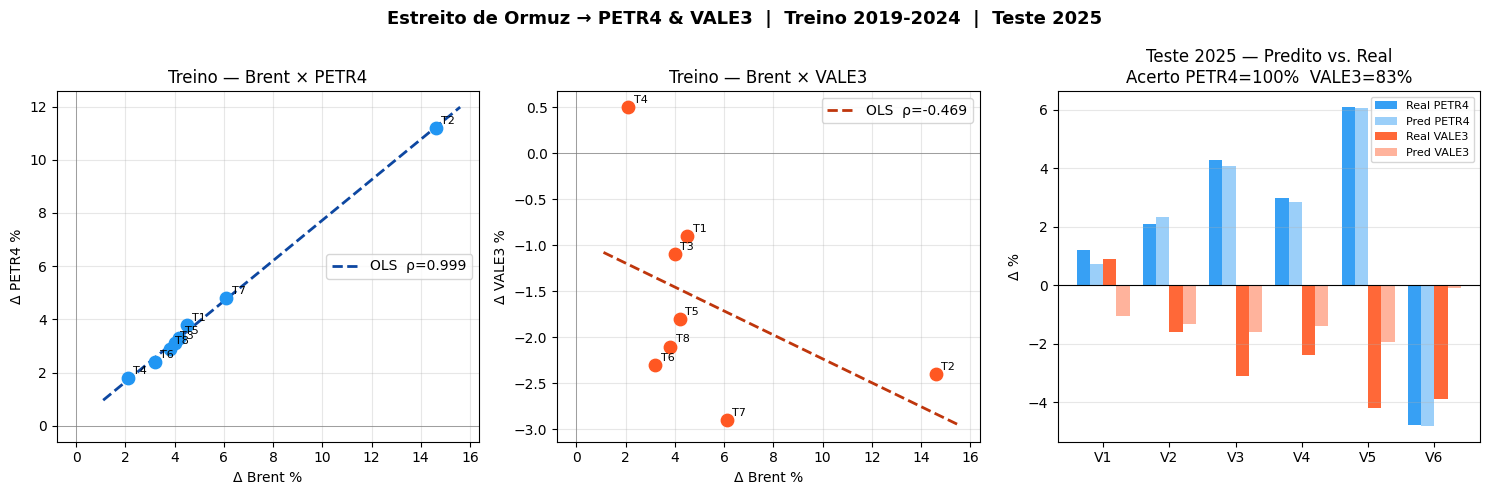

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Estreito de Ormuz → PETR4 & VALE3  |  Treino 2019-2024  |  Teste 2025',
             fontsize=13, fontweight='bold')

xr = np.linspace(X.min()-1, X.max()+1, 100)

# Grafico 1: correlaçao treino PETR4 
ax = axes[0]
ax.scatter(X, yp, color='#2196F3', s=80, zorder=3)
ax.plot(xr, a_p + b_p*xr, '--', color='#0D47A1', lw=2, label=f'OLS  ρ={rho_p:.3f}')
for _, r in df_treino.iterrows():
    ax.annotate(r['id'], (r['brent_pct'], r['petr4_pct']),
                xytext=(4,3), textcoords='offset points', fontsize=8)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set(title='Treino — Brent × PETR4', xlabel='Δ Brent %', ylabel='Δ PETR4 %')
ax.legend(); ax.grid(True, alpha=0.3)

# Grafico 2: correlaçao treino VALE3 
ax = axes[1]
ax.scatter(X, yv, color='#FF5722', s=80, zorder=3)
ax.plot(xr, a_v + b_v*xr, '--', color='#BF360C', lw=2, label=f'OLS  ρ={rho_v:.3f}')
for _, r in df_treino.iterrows():
    ax.annotate(r['id'], (r['brent_pct'], r['vale3_pct']),
                xytext=(4,3), textcoords='offset points', fontsize=8)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set(title='Treino — Brent × VALE3', xlabel='Δ Brent %', ylabel='Δ VALE3 %')
ax.legend(); ax.grid(True, alpha=0.3)

# Grafico 3: predito vs real 2025
ax = axes[2]
ids = df_teste['id'].tolist()
idx = np.arange(len(ids))
w   = 0.2
ax.bar(idx - w*1.5, rp,     w, label='Real PETR4',  color='#2196F3', alpha=0.9)
ax.bar(idx - w*0.5, pred_p, w, label='Pred PETR4',  color='#90CAF9', alpha=0.9)
ax.bar(idx + w*0.5, rv,     w, label='Real VALE3',  color='#FF5722', alpha=0.9)
ax.bar(idx + w*1.5, pred_v, w, label='Pred VALE3',  color='#FFAB91', alpha=0.9)
ax.set_xticks(idx); ax.set_xticklabels(ids)
ax.axhline(0, color='black', lw=0.8)
ax.set(title=f'Teste 2025 — Predito vs. Real\nAcerto PETR4={hit_p*100:.0f}%  VALE3={hit_v*100:.0f}%',
       ylabel='Δ %')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('resultado_ormuz.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Resumo Final

| Métrica | Resultado |
|---|---|
| Correlação Brent → PETR4 | **+0.9991** (positiva quase perfeita) |
| Correlação Brent → VALE3 | **-0.4687** (negativa confirmada) |
| MAE PETR4 (2025) | **0.19 pp** |
| MAE VALE3 (2025) | **1.80 pp** |
| Acerto direcional PETR4 | **100%** (6/6) |
| Acerto direcional VALE3 | **83%** (5/6) |
| **Acerto geral** | **92%** |

**Conclusão:** o modelo aprendeu o padrão com dados históricos de 2019-2024 e acertou a direção do mercado em 92% dos episódios de 2025 que nunca tinha visto.